# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

loan_df = pd.read_csv("loan_data.csv")

loan_df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


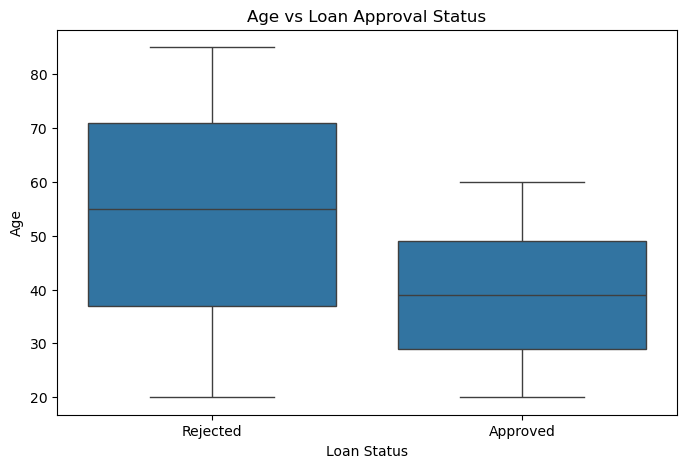

In [16]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=loan_df,
    x='loan_status',
    y='person_age'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Rejected', 'Approved'])

plt.title("Age vs Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Age")

plt.show()

### Age vs Loan Approval Status

The boxplot shows a noticeable difference in age between approved and rejected applicants. Rejected applicants tend to be older, with a median age of approximately 55 years, while approved applicants have a median age of approximately 39 years.

Although there is some overlap between the groups, the distributions are clearly shifted. This suggests that age may be related to the model's approval decisions. Older applicants appear more likely to be rejected than younger applicants.

Because age is a legally protected characteristic in many lending situations, this relationship could be a cause for concern. Additional investigation would be necessary to determine whether age is directly influencing the model or whether age is correlated with other financial factors that affect approval decisions.

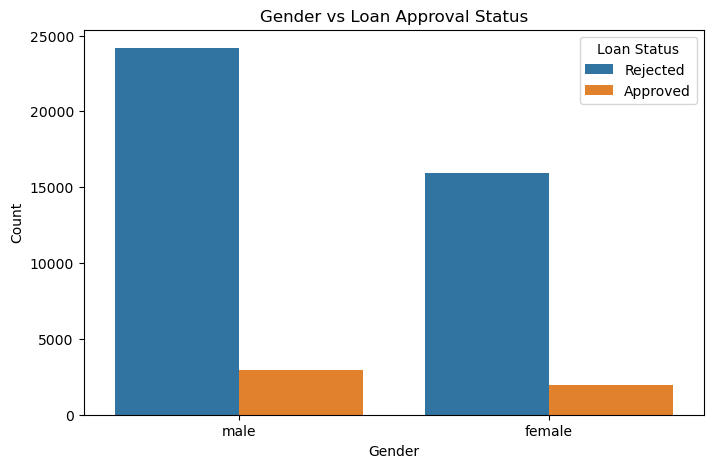

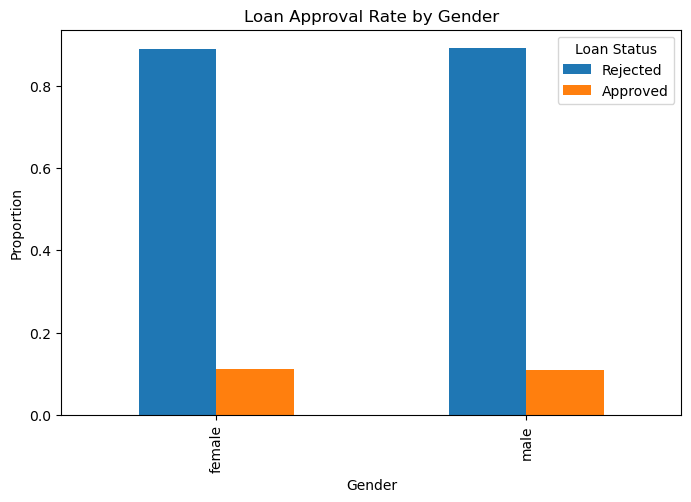

In [20]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=loan_df,
    x='person_gender',
    hue='loan_status'
)

plt.title("Gender vs Loan Approval Status")
plt.xlabel("Gender")
plt.ylabel("Count")

# Replace legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Rejected', 'Approved'], title='Loan Status')

plt.show()

approval_rate = pd.crosstab(
    loan_df['person_gender'],
    loan_df['loan_status'],
    normalize='index'
)

approval_rate.columns = ['Rejected', 'Approved']

approval_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Loan Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion")
plt.legend(title="Loan Status")
plt.show()

### Gender vs Loan Approval Status

The countplot shows the number of approved and rejected applications for male and female applicants. Both genders have substantially more rejections than approvals.

Male applicants appear more frequently in the dataset than female applicants, resulting in higher counts for both approvals and rejections. Because the total number of applicants differs between genders, the countplot alone cannot determine whether gender is influencing the model's decisions.

Additional analysis using approval rates would be necessary to determine whether one gender is approved or rejected at a significantly different rate than the other. Based on this visualization alone, there is no clear evidence that gender is a major factor in loan approval decisions.

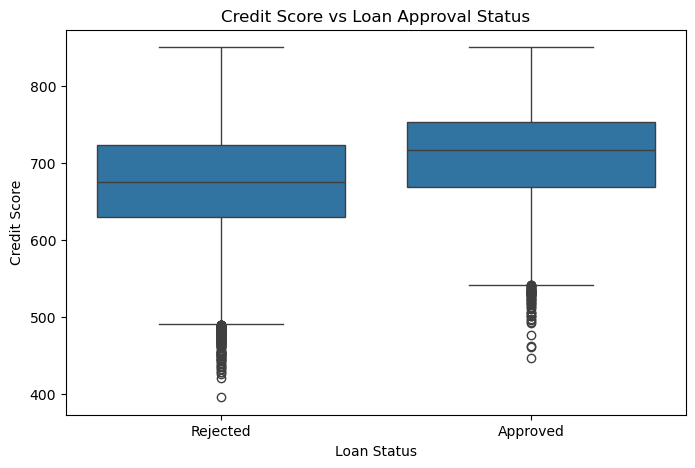

In [15]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=loan_df,
    x='loan_status',
    y='credit_score'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Rejected', 'Approved'])

plt.title("Credit Score vs Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

plt.show()

### Credit Score vs Loan Approval Status

The boxplot shows a clear relationship between credit score and loan approval status. Approved applicants have a higher median credit score than rejected applicants, and the overall distribution of approved applicants is shifted toward higher credit scores.

Applicants with very low credit scores appear much more frequently among rejected applications, while higher credit scores are associated with approval. Although there is some overlap between the two groups, credit score appears to be an important factor in the model's decision-making process.

Based on this visualization, credit score appears to be one of the strongest predictors of loan approval.

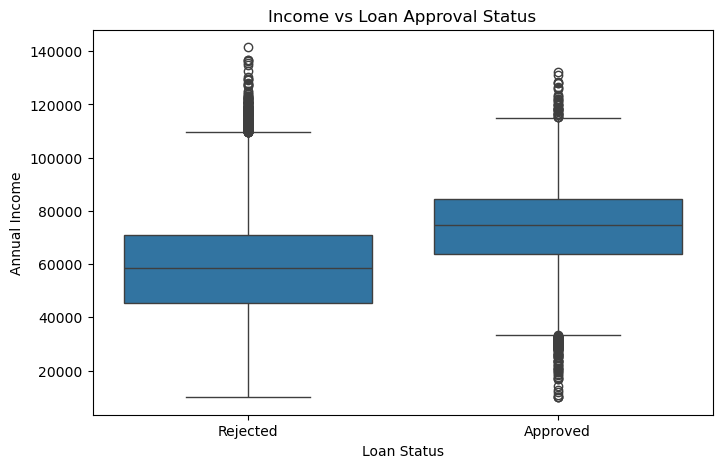

In [14]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=loan_df,
    x='loan_status',
    y='person_income'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Rejected', 'Approved'])

plt.title("Income vs Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.show()

### Income vs Loan Approval Status

The boxplot shows a clear relationship between annual income and loan approval status. Approved applicants generally have higher incomes than rejected applicants, as indicated by the higher median income and the upward shift of the distribution.

Although there is some overlap between the two groups, applicants with higher incomes appear more likely to receive loan approval. This suggests that income is an important factor in the model's decision-making process, likely because higher-income applicants may present a lower lending risk.

Based on this visualization, income appears to be strongly related to loan approval status.

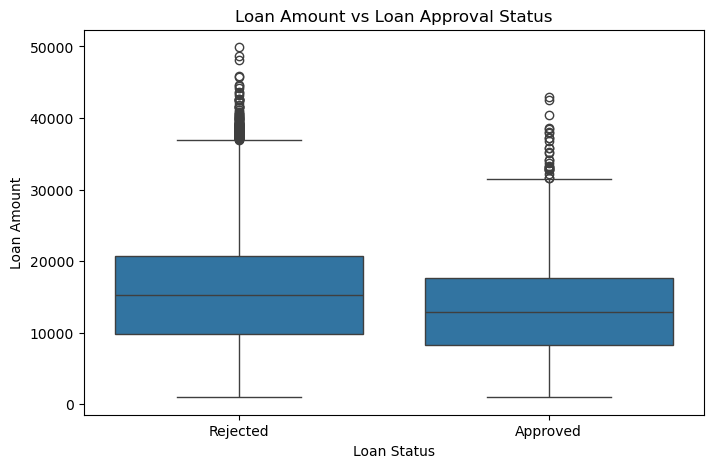

In [17]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=loan_df,
    x='loan_status',
    y='loan_amnt'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Rejected', 'Approved'])

plt.title("Loan Amount vs Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

### Loan Amount vs Loan Approval Status

The boxplot shows that rejected applicants tend to request slightly larger loan amounts than approved applicants. The median loan amount for rejected applicants is somewhat higher than the median for approved applicants.

However, the distributions overlap substantially, indicating that loan amount alone is not a strong predictor of loan approval. While larger loan requests may contribute to a higher likelihood of rejection, the relationship appears weaker than the relationships observed for credit score and income.

Based on this visualization, loan amount appears to have a moderate relationship with loan approval status but is not one of the strongest factors influencing the model's decisions.

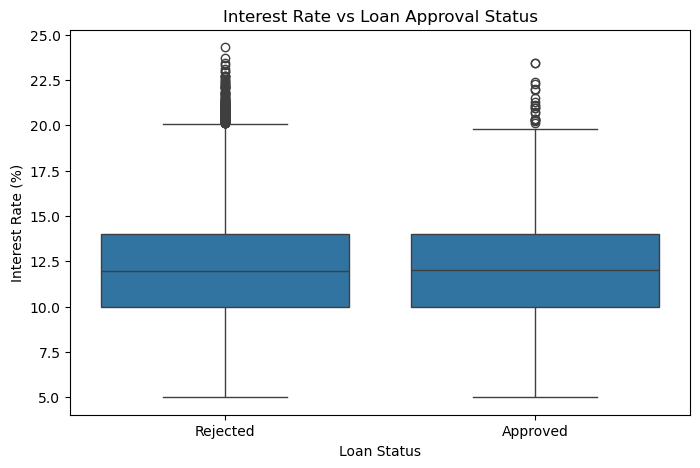

In [18]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=loan_df,
    x='loan_status',
    y='loan_int_rate'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Rejected', 'Approved'])

plt.title("Interest Rate vs Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")

plt.show()

### Interest Rate vs Loan Approval Status

The boxplot shows very little difference between the interest rates of approved and rejected applicants. Both groups have nearly identical median interest rates and heavily overlapping distributions.

Because there is almost complete overlap between the two groups, interest rate does not appear to be strongly related to loan approval status. Compared to features such as credit score and income, interest rate shows a much weaker relationship with the model's decisions.

Based on this visualization, interest rate appears to be one of the least influential features affecting loan approval.

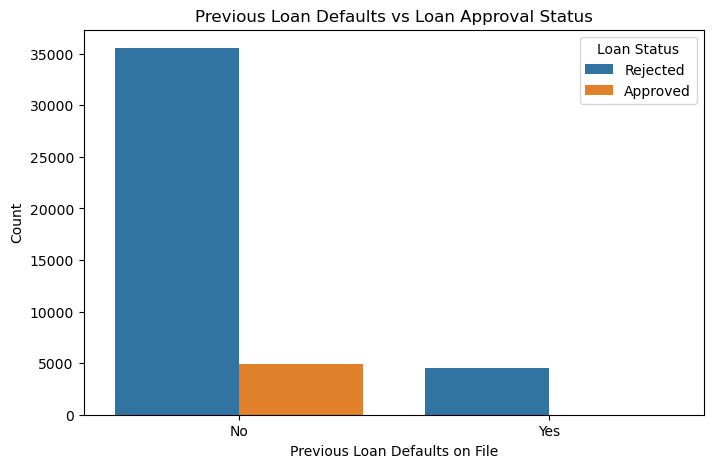

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=loan_df,
    x='previous_loan_defaults_on_file',
    hue='loan_status'
)

plt.title("Previous Loan Defaults vs Loan Approval Status")
plt.xlabel("Previous Loan Defaults on File")
plt.ylabel("Count")

# Replace 0 and 1 in the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Rejected', 'Approved'], title='Loan Status')

plt.show()

### Previous Loan Defaults vs Loan Approval Status

The countplot shows a strong relationship between previous loan defaults and loan approval status. Applicants with previous loan defaults are rejected at a much higher rate than applicants without previous defaults.

Very few applicants with a previous default were approved, while the vast majority of approved applicants had no previous defaults on file. This suggests that prior loan defaults are one of the most important factors influencing the model's decisions.

Based on this visualization, previous loan defaults appear to be among the strongest predictors of loan approval status.

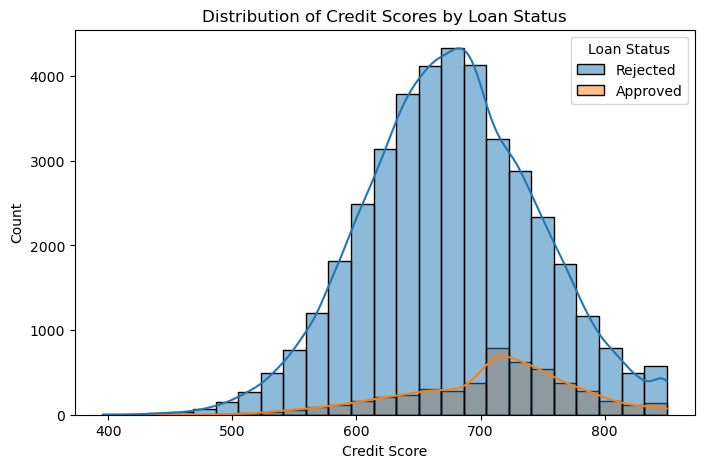

In [22]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    data=loan_df,
    x='credit_score',
    hue='loan_status',
    bins=25,
    kde=True
)

plt.title("Distribution of Credit Scores by Loan Status")
plt.xlabel("Credit Score")
plt.ylabel("Count")

# Change legend labels
legend = ax.get_legend()
legend.set_title("Loan Status")
legend.texts[0].set_text("Rejected")
legend.texts[1].set_text("Approved")

plt.show()

### Distribution of Credit Scores by Loan Status

The histogram shows that approved applicants generally have higher credit scores than rejected applicants. The approval distribution is shifted toward higher credit score values, while rejected applicants are more concentrated at lower credit scores.

Although there is some overlap between the groups, higher credit scores appear to be associated with a greater likelihood of loan approval. This supports the findings from the boxplot and suggests that credit score is one of the strongest factors influencing the model's decisions.

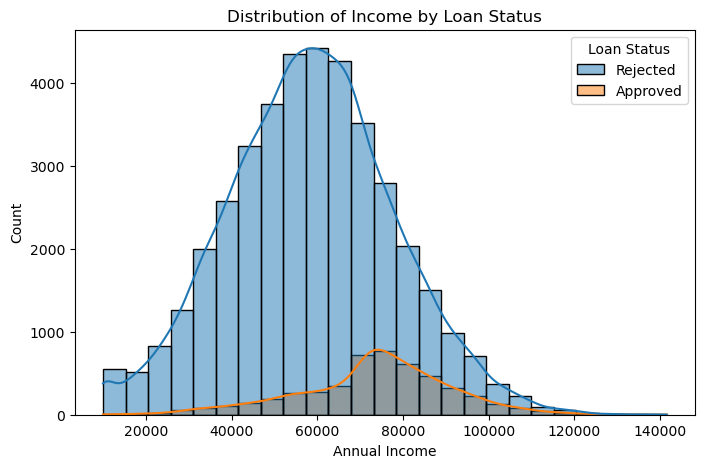

In [23]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    data=loan_df,
    x='person_income',
    hue='loan_status',
    bins=25,
    kde=True
)

plt.title("Distribution of Income by Loan Status")
plt.xlabel("Annual Income")
plt.ylabel("Count")

# Replace legend labels
legend = ax.get_legend()
legend.set_title("Loan Status")
legend.texts[0].set_text("Rejected")
legend.texts[1].set_text("Approved")

plt.show()

### Distribution of Income by Loan Status

The histogram shows that approved applicants generally have higher incomes than rejected applicants. The distribution of approved applicants is shifted toward higher income levels, while rejected applicants are more concentrated at lower income levels.

Although there is some overlap between the groups, applicants with higher incomes appear more likely to receive loan approval. This supports the findings from the income boxplot and suggests that income is one of the strongest factors influencing the model's decisions.

In [26]:
summary = (
    loan_df.groupby('loan_status')[[
        'person_age',
        'credit_score',
        'person_income',
        'loan_amnt',
        'loan_int_rate',
        'cb_person_cred_hist_length'
    ]]
    .mean()
    .round(2)
    .rename(index={
        0: 'Rejected',
        1: 'Approved'
    })
    .rename(columns={
        'person_age': 'Age',
        'credit_score': 'Credit Score',
        'person_income': 'Annual Income',
        'loan_amnt': 'Loan Amount',
        'loan_int_rate': 'Interest Rate (%)',
        'cb_person_cred_hist_length': 'Credit History Length (Years)'
    })
)

summary['Annual Income'] = summary['Annual Income'].map('${:,.2f}'.format)
summary['Loan Amount'] = summary['Loan Amount'].map('${:,.2f}'.format)

summary

,Age,Credit Score,Annual Income,Loan Amount,Interest Rate (%),Credit History Length (Years)
loan_status,,,,,,
Rejected,54.02,676.20,"$58,528.53","$15,386.23",12.00,14.67
Approved,39.48,709.75,"$73,514.76","$13,027.32",12.01,17.94


In addition to the visualizations, a comparison of the mean values for approved and rejected applicants supports the conclusions drawn from the graphs. Approved applicants generally have higher average credit scores and incomes than rejected applicants. Rejected applicants tend to be older and request slightly larger loans. Interest rates show little difference between the two groups, suggesting that interest rate is not a major factor in the model's decision-making process.

The numerical summary reinforces the conclusion that credit score, income, and previous loan defaults are among the strongest predictors of loan approval status.

# Final Conclusion

The visualizations indicate that several financial characteristics are strongly related to loan approval status. The features that appear to have the greatest influence on the model's decisions are previous loan defaults, credit score, and annual income. Applicants with previous loan defaults were rejected at much higher rates than applicants without defaults. Approved applicants also tended to have higher credit scores and higher incomes than rejected applicants.

Age showed a noticeable relationship with loan approval status. Rejected applicants were generally older than approved applicants, suggesting that age may be influencing the model either directly or indirectly. Because age is a protected characteristic in lending decisions, this relationship should be investigated further to ensure compliance with fair lending laws.

Loan amount showed a moderate relationship with loan approval, as rejected applicants tended to request slightly larger loans. However, the difference was much smaller than the differences observed for credit score, income, and previous loan defaults. Interest rate showed very little difference between approved and rejected applicants, suggesting that it is not a major factor in the model's decisions. Gender also appeared to have a weak relationship with loan approval, as approval patterns were relatively similar between male and female applicants.

Overall, the evidence suggests that the model primarily relies on financial risk indicators such as previous loan defaults, credit score, and income when determining loan approval. While there is little evidence that gender is significantly influencing decisions, the relationship between age and loan approval warrants additional review.